# Exploratory Data Analysis — Building Energy Consumption Dataset

This notebook systematically explores the building energy consumption dataset before any modelling.
Goals:
- Understand class balance across the three building types.
- Inspect per-feature distributions and identify potential separability.
- Quantify inter-feature correlations.
- Surface any data-quality concerns (missing values, outliers).

**Target variable:** `Building Type` — Residential (0), Commercial (1), Industrial (2)  
**Input features:** Square Footage, Number of Occupants, Appliances Used, Average Temperature, Day of Week, Energy Consumption

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from src.data import load_raw, LABEL_MAP, CLASSES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
LABEL_MAP = {'Residential': 0, 'Commercial': 1, 'Industrial': 2}

In [11]:
def load_raw(filepath):
    return pd.read_csv(filepath).dropna()

train_df = load_raw('../data/train_energy_data.csv')
test_df = load_raw('../data/test_energy_data.csv')

print(f'Train : {train_df.shape}')
print(f'Test  : {test_df.shape}')
train_df.head()

Train : (1000, 7)
Test  : (100, 7)


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


## Dataset Overview

In [12]:
print('=== Data types ===')
print(train_df.dtypes)
print('\n=== Missing values ===')
print(train_df.isnull().sum())
print('\n=== Descriptive statistics ===')
train_df.describe(include='all')

=== Data types ===
Building Type           object
Square Footage           int64
Number of Occupants      int64
Appliances Used          int64
Average Temperature    float64
Day of Week             object
Energy Consumption     float64
dtype: object

=== Missing values ===
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

=== Descriptive statistics ===


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
count,1000,1000.000,1000.000000,1000.000000,1000.000000,1000,1000.000000
unique,3,NaN,NaN,NaN,NaN,2,NaN
top,Residential,NaN,NaN,NaN,NaN,Weekday,NaN
freq,347,NaN,NaN,NaN,NaN,507,NaN
mean,NaN,25462.388,48.372000,25.606000,22.611390,NaN,4166.252570
std,NaN,14294.554,29.061972,14.105166,7.139943,NaN,933.313064
min,NaN,560.000,1.000000,1.000000,10.050000,NaN,1683.950000
25%,NaN,13169.750,22.000000,13.000000,16.475000,NaN,3509.482500
50%,NaN,25477.000,47.000000,26.000000,22.815000,NaN,4175.730000
75%,NaN,37446.250,73.250000,38.000000,28.850000,NaN,4863.850000


## Class Balance

Class imbalance can bias a classifier toward the majority class and inflate reported accuracy.
We check whether the three building-type classes are roughly equally represented.

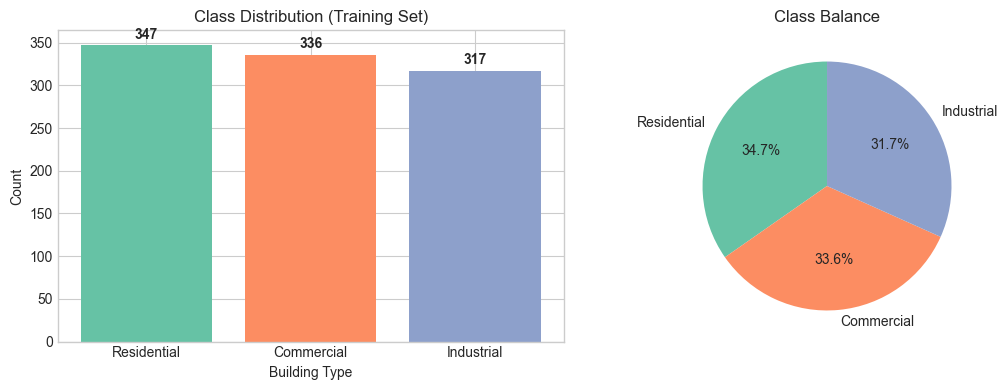

Class counts: {'Residential': 347, 'Commercial': 336, 'Industrial': 317}


In [13]:
counts = train_df['Building Type'].value_counts()
palette = sns.color_palette('Set2', 3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(counts.index, counts.values, color=palette)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, count + 4,
                 str(count), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Class Distribution (Training Set)')
axes[0].set_xlabel('Building Type')
axes[0].set_ylabel('Count')

counts.plot.pie(ax=axes[1], autopct='%1.1f%%', startangle=90, colors=palette)
axes[1].set_ylabel('')
axes[1].set_title('Class Balance')

plt.tight_layout()
plt.show()
print('Class counts:', counts.to_dict())

**Observation:** The three classes are approximately balanced (roughly 33 % each), so class imbalance is not a concern for this dataset.

## Feature Distributions by Building Type

Overlapping histograms reveal how well each feature separates the three classes.
A feature with well-separated peaks is more predictive.

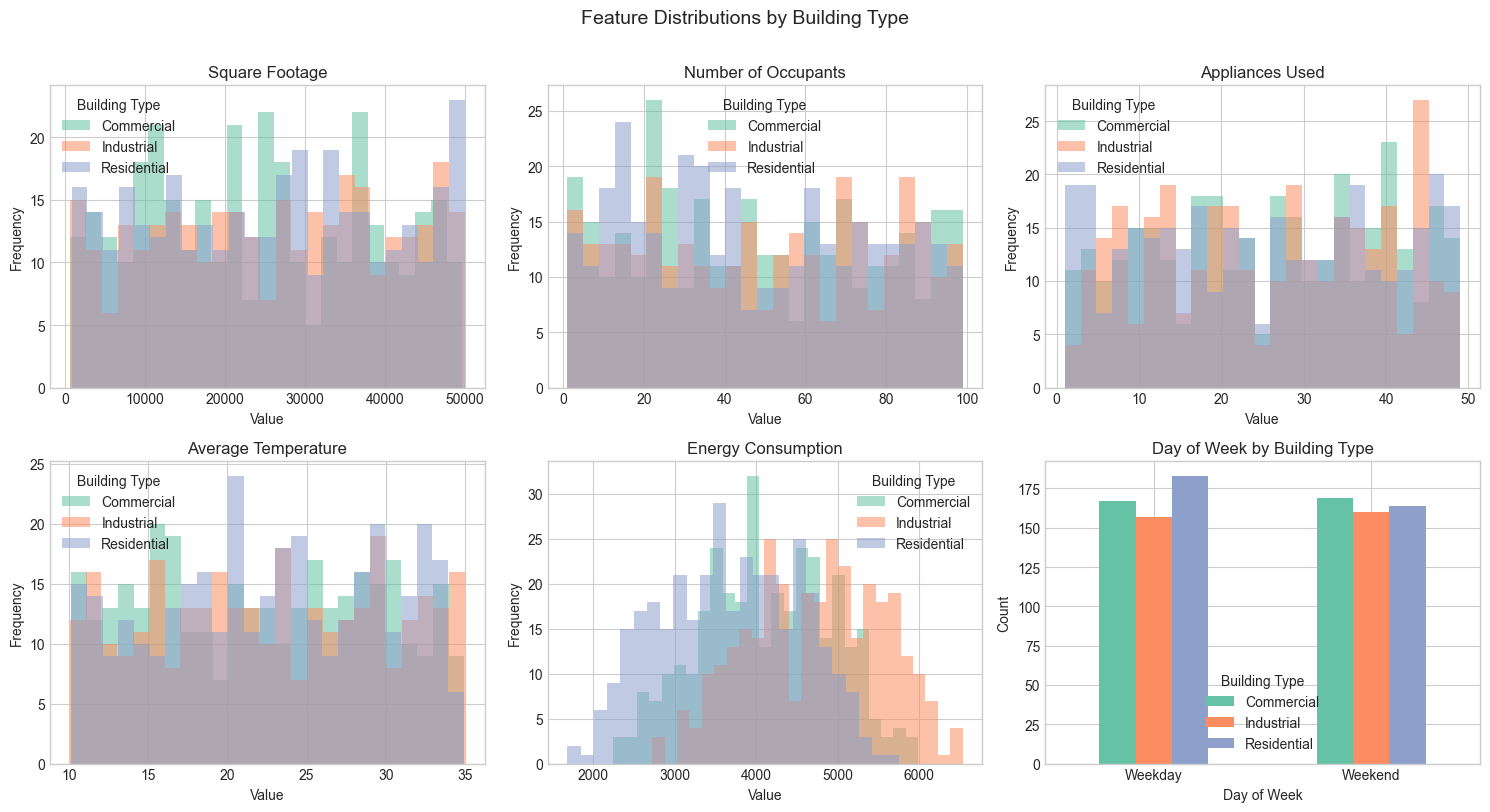

In [14]:
numeric_features = [
    'Square Footage', 'Number of Occupants', 'Appliances Used',
    'Average Temperature', 'Energy Consumption'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()

for idx, feature in enumerate(numeric_features):
    for btype in sorted(train_df['Building Type'].unique()):
        subset = train_df[train_df['Building Type'] == btype][feature]
        axes_flat[idx].hist(subset, alpha=0.55, label=btype, bins=25)
    axes_flat[idx].set_title(feature)
    axes_flat[idx].set_xlabel('Value')
    axes_flat[idx].set_ylabel('Frequency')
    axes_flat[idx].legend(title='Building Type')

# Day of Week distribution
dow = train_df.groupby(['Day of Week', 'Building Type']).size().unstack(fill_value=0)
dow.plot(kind='bar', ax=axes_flat[5], rot=0, color=palette)
axes_flat[5].set_title('Day of Week by Building Type')
axes_flat[5].set_xlabel('Day of Week')
axes_flat[5].set_ylabel('Count')
axes_flat[5].legend(title='Building Type')

plt.suptitle('Feature Distributions by Building Type', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- **Square Footage** and **Energy Consumption** show partial class separation — Industrial buildings tend to be larger and consume more energy.
- **Number of Occupants** and **Appliances Used** distributions largely overlap across classes, suggesting limited discriminative power on their own.
- **Average Temperature** appears class-independent, consistent with it being an environmental measurement rather than a structural property.
- **Day of Week** is evenly split between Weekday and Weekend for all classes — it is unlikely to be a useful predictor.

## Class Separability — Boxplots

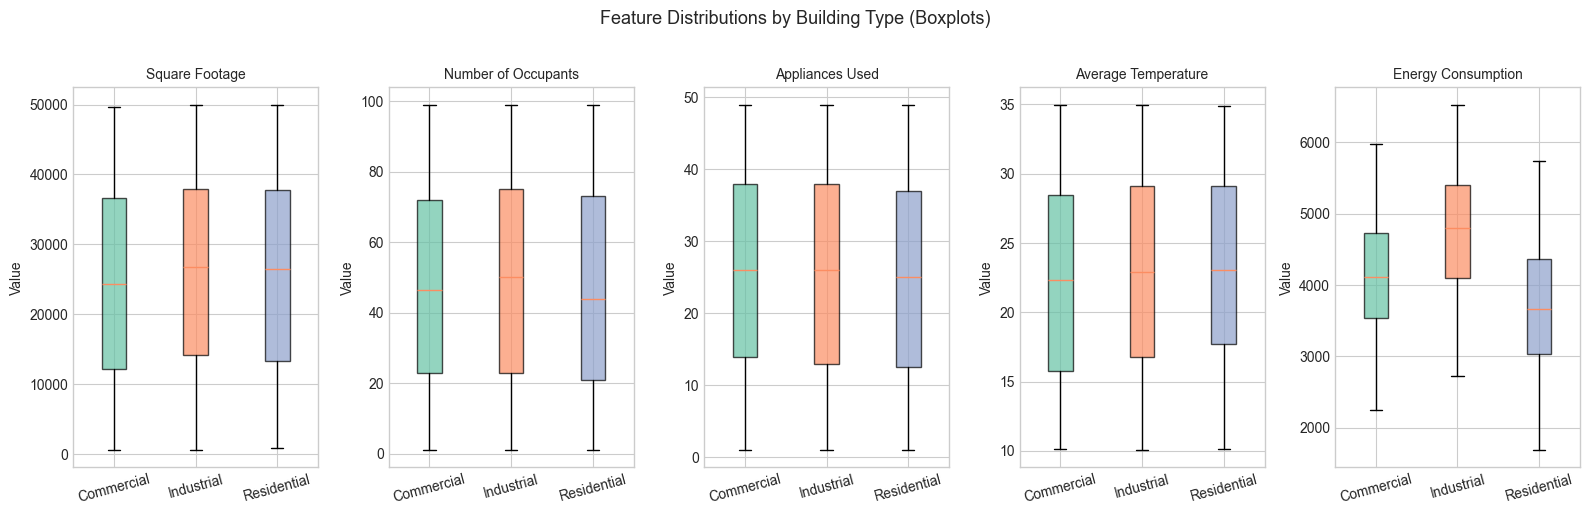

In [15]:
btypes = sorted(train_df['Building Type'].unique())

fig, axes = plt.subplots(1, len(numeric_features), figsize=(16, 5))
for ax, feature in zip(axes, numeric_features):
    groups = [train_df[train_df['Building Type'] == bt][feature].values for bt in btypes]
    bp = ax.boxplot(groups, tick_labels=btypes, patch_artist=True)
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feature, fontsize=10)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Feature Distributions by Building Type (Boxplots)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Correlation Analysis

The Pearson correlation matrix identifies redundant features and shows which inputs
are most linearly associated with the target.

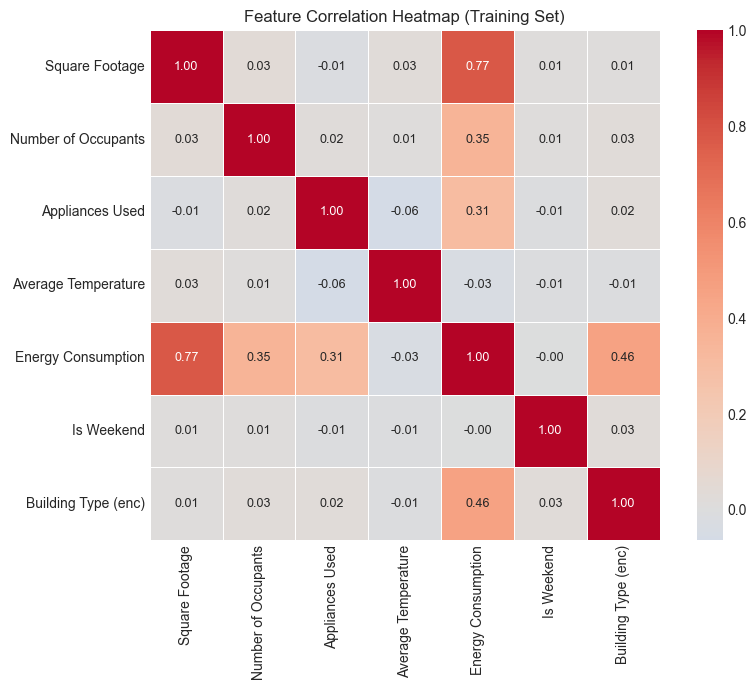

In [16]:
numeric_df = train_df.copy()
numeric_df['Building Type (enc)'] = train_df['Building Type'].map(LABEL_MAP)
numeric_df['Is Weekend'] = (train_df['Day of Week'] == 'Weekend').astype(int)

corr_cols = [
    'Square Footage', 'Number of Occupants', 'Appliances Used',
    'Average Temperature', 'Energy Consumption',
    'Is Weekend', 'Building Type (enc)'
]
corr = numeric_df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap (Training Set)', fontsize=12)
plt.tight_layout()
plt.show()

**Observations:**
- **Square Footage** and **Energy Consumption** have the strongest positive correlations with `Building Type (enc)`, confirming they carry the most predictive signal.
- **Square Footage** and **Energy Consumption** are also highly correlated with each other, which may cause slight redundancy.
- **Average Temperature** and **Is Weekend** show near-zero correlation with the target — they add little discriminative information.
- No severe multicollinearity issues among the remaining features.

## Pairplot — Key Features

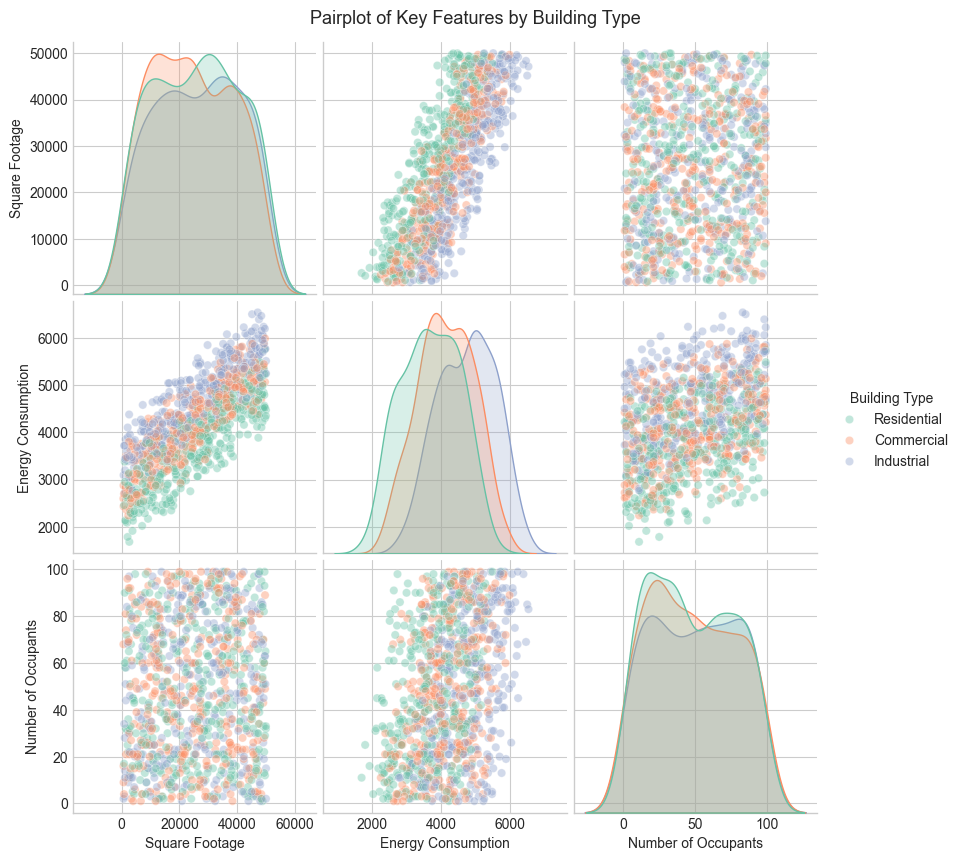

In [17]:
pair_df = train_df[['Square Footage', 'Energy Consumption',
                     'Number of Occupants', 'Building Type']].copy()
g = sns.pairplot(pair_df, hue='Building Type',
                 plot_kws={'alpha': 0.4}, diag_kind='kde', height=2.8)
g.fig.suptitle('Pairplot of Key Features by Building Type', y=1.02, fontsize=13)
plt.show()

**Observations:**
- The **Square Footage vs. Energy Consumption** scatter shows partial but noisy class separation — the two features together form the main 2-D decision space used in model training.
- Classes overlap considerably, suggesting a theoretical accuracy ceiling well below 100% with only these two features.

## Summary of EDA Findings

| Feature | Predictive Signal | Notes |
|---|---|---|
| Square Footage | **High** | Strongest single predictor |
| Energy Consumption | **High** | Correlated with Square Footage |
| Number of Occupants | Low | Broad overlap across classes |
| Appliances Used | Low | Broad overlap across classes |
| Average Temperature | Very low | Environment-dependent, class-agnostic |
| Day of Week | Very low | Uniform distribution across classes |

**Modelling implication:** Using only Square Footage and Energy Consumption as features is a reasonable starting point, but the significant class overlap means we should expect a test-set accuracy ceiling around 65–70 % with linear or shallow non-linear models.